# First things first, السلام عليكم ورحمة الله وبركاته 🫡🩵

### Welcome to my humble experiment trying different smoothing and sharpening techniques

### To be able to see their effect, we need first a noisy picture, so let's get some pictures and add some noise 😶‍🌫️

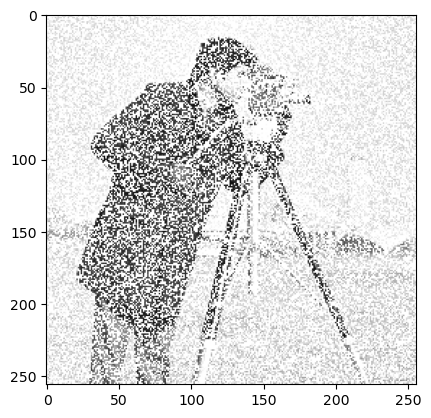

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("test_images/cameraman.bmp", cv2.IMREAD_GRAYSCALE)

mean = 0
std = 25
guass = np.random.normal(mean, std, img.shape).astype('uint8')
noisy_img = cv2.add(img, guass)
plt.imshow(noisy_img, cmap = 'gray')

### We have the image, let's get smooooothing 😎

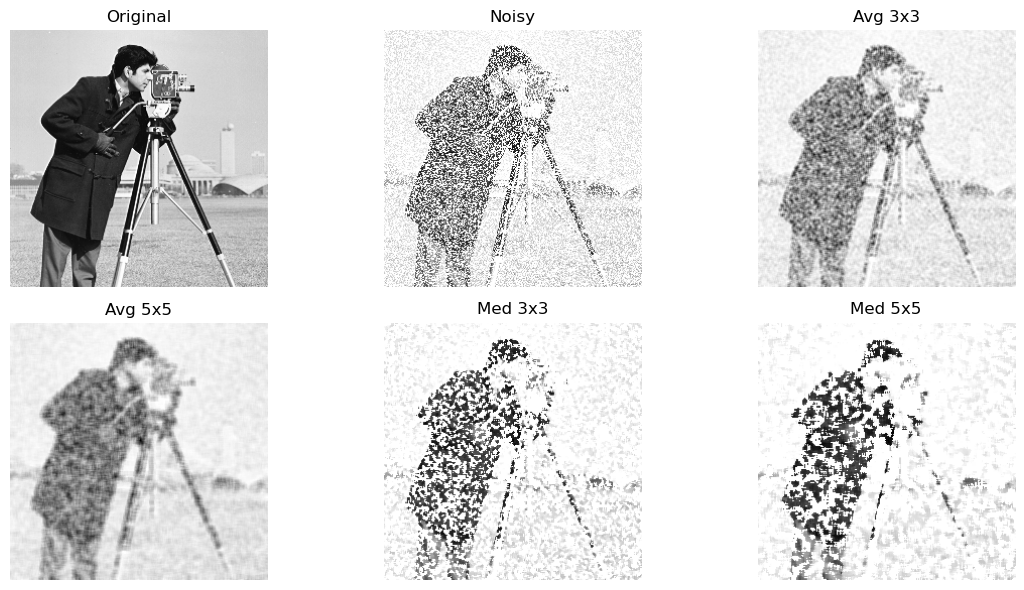

In [9]:
avg_3 = cv2.blur(noisy_img, (3, 3))
avg_5 = cv2.blur(noisy_img, (5, 5))
med_3 = cv2.medianBlur(noisy_img, 3)
med_5 = cv2.medianBlur(noisy_img, 5)

titles = ['Original', 'Noisy', 'Avg 3x3', 'Avg 5x5', 'Med 3x3', 'Med 5x5']
images = [img, noisy_img, avg_3, avg_5, med_3, med_5]

plt.figure(figsize = (12, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap = 'gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

### Since we are done smoothing, let's get sharpening 🔪

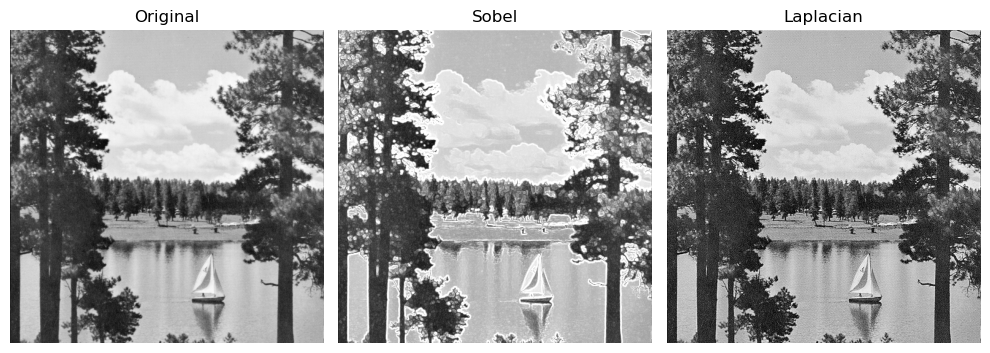

In [11]:
img2 = cv2.imread("test_images/sailboat.bmp", cv2.IMREAD_GRAYSCALE)

# Sobel filters
sobelx = cv2.Sobel(img2, cv2.CV_64F, 1,0, ksize = 3)
sobely = cv2.Sobel(img2, cv2.CV_64F, 0,1, ksize = 3)
sobel = cv2.magnitude(sobelx, sobely)
sharpened_sobel = cv2.convertScaleAbs(img2 + 0.5 * sobel)
# Laplacian filter
laplacian = cv2.Laplacian(img2, cv2.CV_64F)
sharpened_lap = cv2.convertScaleAbs(img2 - 0.7 * laplacian)

# Show results
titles2 = ['Original', 'Sobel', 'Laplacian']
images2 = [img2, sharpened_sobel, sharpened_lap]

plt.figure(figsize = (10, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images2[i], cmap = 'gray')
    plt.title(titles2[i])
    plt.axis('off')

plt.tight_layout()
plt.show()